In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Carregar os dados
df = pd.read_csv('/Users/utilizador/Documents/IA-Esmad/datasets/diabetes.csv')

In [85]:
# Lista de colunas onde o valor 0 é na verdade um erro de preenchimento
cols_com_erro = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','Pregnancies']

# Substituímos 0 por NaN e depois pela mediana da respetiva coluna
for col in cols_com_erro:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("Dados limpos! Zeros impossíveis foram removidos.")

Dados limpos! Zeros impossíveis foram removidos.


In [86]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Usamos o stratify para garantir que a proporção de diabéticos seja igual no treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [87]:
# Criamos o modelo com "poda" (pruning)
model = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=5,           # Limita o tamanho da árvore
    min_samples_leaf=15,   # Exige que cada grupo final tenha pelo menos 15 pessoas
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=15,
                       random_state=42)

In [88]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f'Acurácia Treino: {train_accuracy:.4f}')
print(f'Acurácia Teste:  {test_accuracy:.4f}')


Acurácia Treino: 0.7883
Acurácia Teste:  0.8052


In [89]:
#calcula a acuracy do modelo com os dados de treino

from sklearn.metrics import accuracy_score
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print('Acurácia do modelo nos dados de treino: ', train_accuracy)

Acurácia do modelo nos dados de treino:  0.7882736156351792


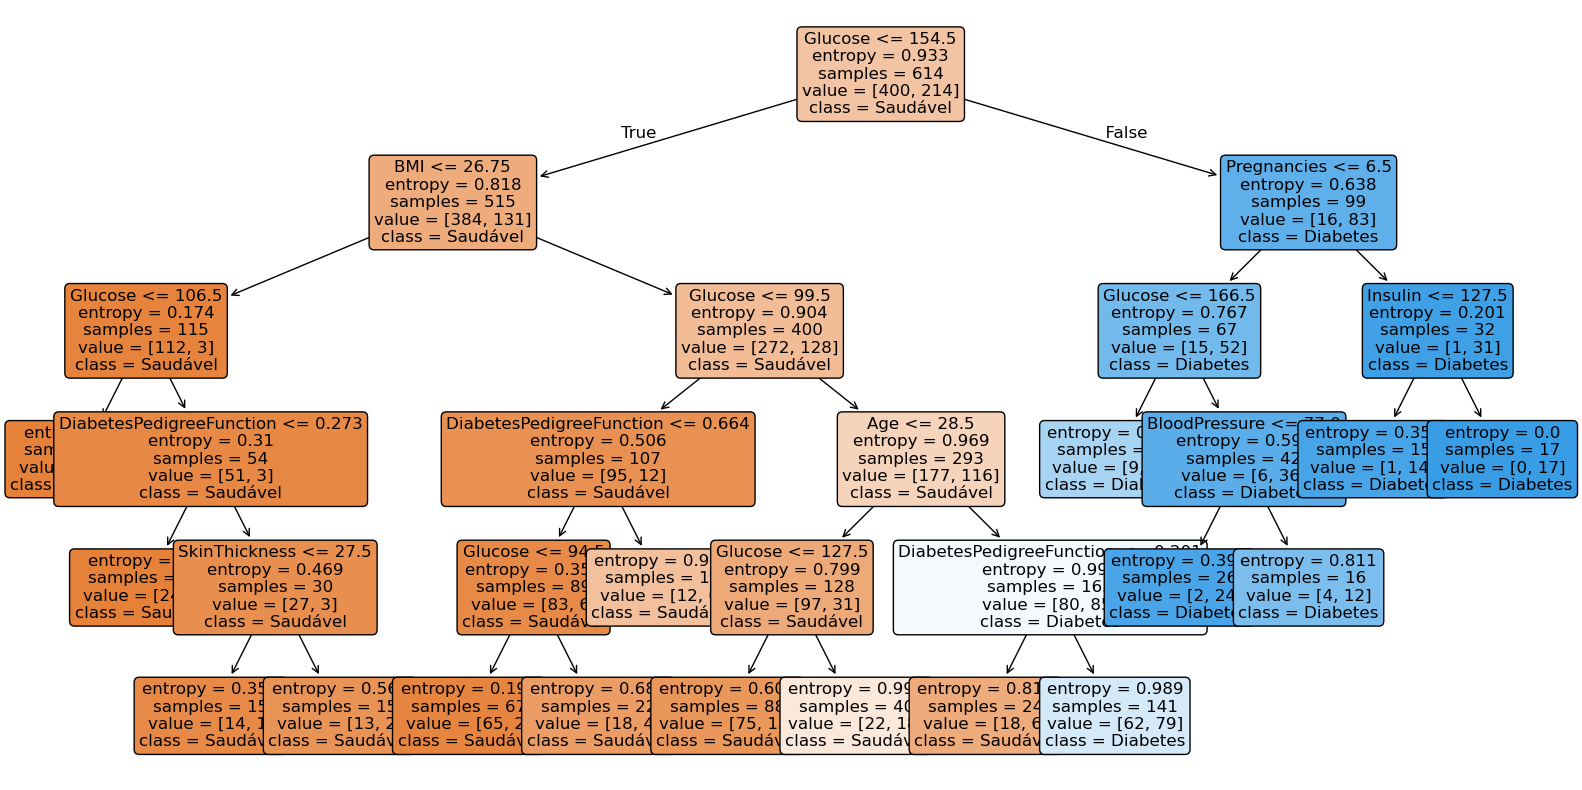

In [90]:
plt.figure(figsize=(20,10))
plot_tree(model, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['Saudável', 'Diabetes'],
          rounded=True,
          fontsize=12)
plt.show()

In [92]:
#calcula a acuracy do modelo com os dados de teste e treino

print('Acurácia do modelo nos dados de teste: ', test_accuracy)
print('Acurácia do modelo nos dados de treino: ', train_accuracy)



Acurácia do modelo nos dados de teste:  0.8051948051948052
Acurácia do modelo nos dados de treino:  0.7882736156351792
